# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [1]:

# --- 1. PROCESAMIENTO DE DATOS Y UTILIDADES ---
import pandas as pd
import numpy as np
import os

# --- 2. CONEXIÓN A BASES DE DATOS (SQL) ---
from sqlalchemy import create_engine, inspect

# --- 3. VISUALIZACIÓN DE DATOS ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- 4. ANÁLISIS ESTADÍSTICO ---
from scipy import stats as st
from statsmodels.stats.proportion import proportions_ztest



In [2]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [3]:
# explorar datasets
display(orders.head())

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [4]:
display(catalog.head())

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


In [5]:
display(marketing.head())

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [6]:
# ---------- Paso 1.2: Limpieza Avanzada y Auditoría de Impacto ----------
# Revisión dataset original
orders.info()

# 1. Crear copia de seguridad y registrar tamaño inicial
orders_clean = orders.copy()
filas_inicio = len(orders_clean)

# 2. Estandarizar texto y normalizar "Mexico" para Power BI
text_cols = ['pais', 'dispositivo', 'fuente_referencia', 'nombre_producto', 'categoria_producto']
for col in text_cols:
    # Normalizamos a formato Título (ej. "mexico" -> "Mexico")
    orders_clean[col] = orders_clean[col].str.strip().str.title()

# 3. Convertir fecha al formato correcto (Datetime)
orders_clean['fecha_hora_pedido'] = pd.to_datetime(orders_clean['fecha_hora_pedido'], errors='coerce')

# 4. Eliminar filas con nulos en columnas críticas y registrar impacto
pre_nulos = len(orders_clean)
cols_criticas = [
    'cantidad', 'precio_unitario', 'monto_descuento', 'monto_total',
    'pais', 'fecha_hora_pedido', 'dispositivo', 'nombre_producto'
]
orders_clean = orders_clean.dropna(subset=cols_criticas)
eliminadas_nulos = pre_nulos - len(orders_clean)

# 5. Filtrar valores imposibles
pre_invalidos = len(orders_clean)
orders_clean = orders_clean[
    (orders_clean['cantidad'] > 0) & 
    (orders_clean['precio_unitario'] > 0) & 
    (orders_clean['monto_descuento'] >= 0) & 
    (orders_clean['monto_total'] >= 0)
]
eliminadas_invalidos = pre_invalidos - len(orders_clean)

# 6. Corregir tipos de datos
orders_clean['cantidad'] = orders_clean['cantidad'].astype(int)

# 7. REPORTE DE TRAZABILIDAD 
filas_final = len(orders_clean)
total_eliminadas = filas_inicio - filas_final

print("--- REPORTE DE TRAZABILIDAD DE LIMPIEZA ---")
print(f"Registros originales: {filas_inicio}")
print(f"(-) Filas con nulos o fechas inválidas: {eliminadas_nulos}")
print(f"(-) Filas con valores imposibles o montos negativos: {eliminadas_invalidos}")
print(f"Registros finales limpios: {filas_final}")
print(f"Impacto total: {total_eliminadas} filas removidas ({ (total_eliminadas/filas_inicio):.2%})")
print(f"Nota: El país ha sido normalizado ejemplo'mexico'  a 'Mexico' para consistencia.")

print("\n--- Diagnóstico Final de 'orders_clean' ---")
orders_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB
--- REPORTE DE TRAZABILIDAD DE LIMPIEZA ---
Registros originales: 25100
(-) Filas con nulos o fechas inválidas: 400
(-) Filas con valores imposibles o mo

In [7]:
# ---------- Información inicial del DataFrame ----------
catalog.info()

# 1. Crear copia de seguridad
catalog_clean = catalog.copy()

# 2. Estandarizar texto y ortografía
# Al ser el catálogo nuestra "fuente de la verdad", retiramos la tilde en Electrónica debido a incopatibilidad en PBI
catalog_clean['categoria_producto'] = catalog_clean['categoria_producto'].str.replace('Electrónica', 'Electronica', case=False)

# 3. Normalizar nombres para asegurar el cruce (Merge) con orders_clean
# Aplicamos formato Título y quitamos espacios invisibles
cols_texto = ['nombre_producto', 'categoria_producto']
for col in cols_texto:
    catalog_clean[col] = catalog_clean[col].str.strip().str.title()

# 4. Validación de costos
# Nos aseguramos de que no existan costos de 0 o negativos que arruinen la rentabilidad (aunque la tabla es muy pequeña pero sirve como práctica)
catalog_clean = catalog_clean[catalog_clean['costo_unitario'] > 0]

# 5. Validación final del estado del dataset
print("\n--- Diagnóstico Final de 'catalog_clean' ---")
print(catalog_clean.info())

print("\nValores nulos restantes:")
print(catalog_clean.isna().sum())

# 6. Verificación de integridad (Unicidad)
# Un catálogo no debe tener el mismo producto repetido
duplicados = catalog_clean.duplicated(subset=['nombre_producto']).sum()
print(f"\nCantidad de productos duplicados: {duplicados}")

# 7. Vista previa de los datos normalizados
print("\nVista previa del catálogo:")
print(catalog_clean)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes

--- Diagnóstico Final de 'catalog_clean' ---
<class 'pandas.core.frame.DataFrame'>
Int64Index: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 280.0+ bytes
None

Valores nulos restantes:
nombre_producto      

In [8]:
# ---------- Paso 1.3: Limpieza y Trazabilidad del Dataset de Marketing ----------

## Revisión dataset original
marketing.info()

# 1. Crear copia de seguridad y registrar tamaño inicial
# Mantenemos la trazabilidad 
marketing_clean = marketing.copy()
filas_inicio_mkt = len(marketing_clean)

# 2. Estandarizar texto y normalizar "Mexico" (Sin tilde para Power BI)
# Aseguramos que el cruce de tablas en el Paso 6 sea consistente
marketing_clean['pais'] = marketing_clean['pais'].str.strip().str.title()
marketing_clean['canal'] = marketing_clean['canal'].str.strip().str.title()

# Corrección específica para compatibilidad con orders_clean y Dim_Pais
marketing_clean['pais'] = marketing_clean['pais'].replace('México', 'Mexico')

# 3. Manejo de nulos en 'canal'
# Imputamos con "Unknown" para proteger la integridad del gasto total
marketing_clean['canal'] = marketing_clean['canal'].fillna("Unknown")

# 4. Convertir fecha al formato correcto (Datetime)
marketing_clean['fecha'] = pd.to_datetime(marketing_clean['fecha'], errors='coerce')

# 5. Eliminar filas con nulos en columnas críticas y registrar impacto
pre_nulos_mkt = len(marketing_clean)
marketing_clean = marketing_clean.dropna(subset=['fecha', 'pais', 'gasto'])
eliminadas_nulos_mkt = pre_nulos_mkt - len(marketing_clean)

# 6. Filtrar valores de gasto inválidos
pre_invalidos_mkt = len(marketing_clean)
marketing_clean = marketing_clean[marketing_clean['gasto'] >= 0]
eliminadas_invalidos_mkt = pre_invalidos_mkt - len(marketing_clean)

# 7. REPORTE DE TRAZABILIDAD DE MARKETING
filas_final_mkt = len(marketing_clean)
total_eliminadas_mkt = filas_inicio_mkt - filas_final_mkt

print("--- REPORTE DE TRAZABILIDAD: MARKETING ---")
print(f"Registros originales: {filas_inicio_mkt}")
print(f"(-) Filas con nulos o fechas NaT: {eliminadas_nulos_mkt}")
print(f"(-) Filas con gasto negativo: {eliminadas_invalidos_mkt}")
print(f"Registros finales limpios: {filas_final_mkt}")
print(f"Impacto total: {total_eliminadas_mkt} filas removidas ({ (total_eliminadas_mkt/filas_inicio_mkt):.2%})")
print(f"Nota: Se normalizó 'México' a 'Mexico' para consistencia con el modelo estrella [Sprint 11].")

# 8. Verificación de consistencia final
print("\n--- Diagnóstico de Tipos de Datos ---")
print(marketing_clean.dtypes)
print("\nInversión total por país (Validación de ROI):")
print(marketing_clean.groupby('pais')['gasto'].sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB
--- REPORTE DE TRAZABILIDAD: MARKETING ---
Registros originales: 1620
(-) Filas con nulos o fechas NaT: 0
(-) Filas con gasto negativo: 0
Registros finales limpios: 1620
Impacto total: 0 filas removidas (0.00%)
Nota: Se normalizó 'México' a 'Mexico' para consistencia con el modelo estrella [Sprint 11].

--- Diagnóstico de Tipos de Datos ---
fecha         datetime64[ns]
pais                  object
id_campaña            object
canal                 object
gasto                float64
dtype: object

Inversión total por país (Validación de ROI):
pais


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [9]:
# ---------- Paso 1.4: Exportación Organizada de Datasets Limpios ----------

# 1. Definir la ruta de la carpeta 
# Usamos una subcarpeta para mantener el repositorio ordenado
folder_path = 'data/processed/'

# 2. Crear la carpeta si no existe
# Esto evita errores si es la primera vez que se ejecuta el proceso
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Directorio creado: {folder_path}")

# 3. Exportar los DataFrames a la ruta especificada
# Mantenemos el sufijo '_clean' de lo contrario exportariamos el dataset sin cambios.
orders_clean.to_csv(os.path.join(folder_path, 'orders_clean.csv'), index=False)
catalog_clean.to_csv(os.path.join(folder_path, 'catalog_clean.csv'), index=False)
marketing_clean.to_csv(os.path.join(folder_path, 'marketing_clean.csv'), index=False)

# 4. Confirmación de exportación
print("\n--- ✅ EXPORTACIÓN EXITOSA ---")
print(f"Los datasets han sido guardados en: {folder_path}")
print("Archivos listos para ser cargados")


--- ✅ EXPORTACIÓN EXITOSA ---
Los datasets han sido guardados en: data/processed/
Archivos listos para ser cargados


---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [10]:
# 1. Unir pedidos con catálogo para obtener costos unitarios
# Usamos 'left' para no perder ventas aunque un producto no esté en catálogo
ventas_con_costos = orders_clean.merge(catalog_clean[['nombre_producto', 'costo_unitario']], 
    on='nombre_producto', 
    how='left')

# 2. Calcular el costo de producción total por pedido (Cantidad * Costo Unitario)
ventas_con_costos['costo_produccion_pedido'] = ventas_con_costos['cantidad'] * ventas_con_costos['costo_unitario']

# Calcularemos promedios y rankings para entender qué está impulsando los números anteriores
# 3. Ticket promedio por orden
# Se calcula sobre el monto total de cada transacción
ticket_promedio = orders_clean['monto_total'].mean()

# 4. Cantidad promedio de productos por orden
cantidad_promedio = orders_clean['cantidad'].mean()

# 5. Producto más vendido (por cantidad de unidades)
# Agrupamos por producto y sumamos la cantidad
top_producto = orders_clean.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False).idxmax()
unidades_top = orders_clean.groupby('nombre_producto')['cantidad'].sum().max()

# 6. Gasto en marketing por canal
# Agrupamos el dataset de marketing para ver la distribución de la inversión
gasto_por_canal = marketing_clean.groupby('canal')['gasto'].sum().sort_values(ascending=False)


In [11]:
# --- Cálculo de KPIs de Rentabilidad ---

# A. Ingreso Total (Revenue)
revenue_total = orders_clean['monto_total'].sum()

# B. Costo Total de Producción
costo_produccion_total = ventas_con_costos['costo_produccion_pedido'].sum()

# C. Inversión Total en Marketing
marketing_spend_total = marketing_clean['gasto'].sum()

# D. Ganancia Neta (Profit)
# Profit = Revenue - (Costo Producción + Gasto Marketing)
profit_total = revenue_total - (costo_produccion_total + marketing_spend_total)

In [12]:
print(f"Revenue Total: ${revenue_total:,.2f}")
print(f"Costo de Producción: ${costo_produccion_total:,.2f}")
print(f"Inversión Marketing: ${marketing_spend_total:,.2f}")
print(f"Profit Final: ${profit_total:,.2f}")

if profit_total > 0:
    print("¡El negocio es RENTABLE!")
else:
    print("El negocio NO es rentable actualmente.")

print(f"Ticket promedio: ${ticket_promedio:.2f}")
print(f"Cantidad promedio por orden: {cantidad_promedio:.2f} unidades")
print(f"Producto estrella: {top_producto} ({unidades_top} unidades vendidas)")
print("\nInversión por canal de marketing:")
print(gasto_por_canal)  

Revenue Total: $51,873,170.44
Costo de Producción: $43,095,280.85
Inversión Marketing: $2,871,843.53
Profit Final: $5,906,046.06
¡El negocio es RENTABLE!
Ticket promedio: $2100.13
Cantidad promedio por orden: 7.17 unidades
Producto estrella: Laptop-Gaming-16Gb (144181 unidades vendidas)

Inversión por canal de marketing:
canal
Social         918043.21
Organic        913533.01
Paid_Search    863088.21
Unknown        177179.10
Name: gasto, dtype: float64


---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [27]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [24]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [25]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT 
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
GROUP BY nombre_evento
ORDER BY 
    CASE nombre_evento
        WHEN 'first_visit' THEN 1
        WHEN 'add_to_cart' THEN 2
        WHEN 'add_payment_info' THEN 3
        WHEN 'purchase' THEN 4
        ELSE 5
    END;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios_unicos
0,first_visit,7796
1,add_to_cart,7634
2,add_payment_info,6250
3,purchase,6240
4,begin_checkout,7208
5,select_item,7582


In [26]:
# PARTE 2: Conversiones
# ======================

# --- Análisis de Funnel Secuencial ---

query_conversion = '''
WITH 
-- 1. Usuarios que iniciaron la visita
step1_visit AS (
    SELECT DISTINCT id_usuario FROM events WHERE nombre_evento = 'first_visit'
),
-- 2. Usuarios que visitaron y luego seleccionaron un producto
step2_select AS (
    SELECT DISTINCT e.id_usuario 
    FROM events e 
    INNER JOIN step1_visit prev ON e.id_usuario = prev.id_usuario 
    WHERE e.nombre_evento = 'select_item'
),
-- 3. Usuarios que seleccionaron y luego agregaron al carrito
step3_cart AS (
    SELECT DISTINCT e.id_usuario 
    FROM events e 
    INNER JOIN step2_select prev ON e.id_usuario = prev.id_usuario 
    WHERE e.nombre_evento = 'add_to_cart'
),
-- 4. Usuarios que tenían carrito y pasaron al checkout
step4_checkout AS (
    SELECT DISTINCT e.id_usuario 
    FROM events e 
    INNER JOIN step3_cart prev ON e.id_usuario = prev.id_usuario 
    WHERE e.nombre_evento = 'begin_checkout'
),
-- 5. Usuarios que iniciaron checkout y agregaron info de pago
step5_payment AS (
    SELECT DISTINCT e.id_usuario 
    FROM events e 
    INNER JOIN step4_checkout prev ON e.id_usuario = prev.id_usuario 
    WHERE e.nombre_evento = 'add_payment_info'
),
-- 6. Usuarios que agregaron pago y completaron la compra
step6_purchase AS (
    SELECT DISTINCT e.id_usuario 
    FROM events e 
    INNER JOIN step5_payment prev ON e.id_usuario = prev.id_usuario 
    WHERE e.nombre_evento = 'purchase'
),
-- Consolidación de conteos
funnel_counts AS (
    SELECT
        (SELECT COUNT(*) FROM step1_visit) AS visit,
        (SELECT COUNT(*) FROM step2_select) AS select_it,
        (SELECT COUNT(*) FROM step3_cart) AS cart,
        (SELECT COUNT(*) FROM step4_checkout) AS checkout,
        (SELECT COUNT(*) FROM step5_payment) AS payment,
        (SELECT COUNT(*) FROM step6_purchase) AS purchase
)
-- Salida final con lógica de conversión secuencial (Sugerencia Abia)
SELECT '1. First Visit' AS etapa, visit AS usuarios, 100.0 AS pct_conversion_acumulada, 0.0 AS pct_drop_off FROM funnel_counts
UNION ALL
SELECT '2. Select Item', select_it, ROUND(100.0 * select_it / NULLIF(visit, 0), 2), ROUND(100.0 * (visit - select_it) / NULLIF(visit, 0), 2) FROM funnel_counts
UNION ALL
SELECT '3. Add to Cart', cart, ROUND(100.0 * cart / NULLIF(visit, 0), 2), ROUND(100.0 * (select_it - cart) / NULLIF(select_it, 0), 2) FROM funnel_counts
UNION ALL
SELECT '4. Begin Checkout', checkout, ROUND(100.0 * checkout / NULLIF(visit, 0), 2), ROUND(100.0 * (cart - checkout) / NULLIF(cart, 0), 2) FROM funnel_counts
UNION ALL
SELECT '5. Add Payment Info', payment, ROUND(100.0 * payment / NULLIF(visit, 0), 2), ROUND(100.0 * (checkout - payment) / NULLIF(checkout, 0), 2) FROM funnel_counts
UNION ALL
SELECT '6. Purchase', purchase, ROUND(100.0 * purchase / NULLIF(visit, 0), 2), ROUND(100.0 * (payment - purchase) / NULLIF(payment, 0), 2) FROM funnel_counts;
'''
conversion = pd.read_sql(query_conversion, con=engine)
conversion


,etapa,usuarios,pct_conversion_acumulada,pct_drop_off
0,1. First Visit,7796,100.00,0.00
1,2. Select Item,7393,94.83,5.17
2,3. Add to Cart,7052,90.46,4.61
3,4. Begin Checkout,6364,81.63,9.76
4,5. Add Payment Info,4967,63.71,21.95
5,6. Purchase,3857,49.47,22.35


 Análisis del funnel de conversión secuencial para RappiPlus basado en 7,796 visitas iniciales.

 Se logró una conversión final saludable del 49.47%. Sin embargo, se identificó que el punto de mayor fricción ocurre al cierre, donde el 22.35% de los usuarios que ya ingresaron su pago no completan la compra.

 Se recomienda auditar la estabilidad de la pasarela de pagos y la confirmación final de pedido, ya que es donde se genera la mayor pérdida relativa de usuarios con alta intención de compra.

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [17]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [18]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [19]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohortes AS (
    SELECT 
        id_usuario,
        DATE_TRUNC('month', CAST(fecha_registro AS DATE))::date AS cohorte
    FROM users
),
cohorte_size AS (
    SELECT 
        cohorte,
        COUNT(DISTINCT id_usuario) AS usuarios_iniciales
    FROM cohortes
    GROUP BY cohorte
),
actividad AS (
    SELECT 
        c.cohorte,
        ua.id_usuario,
        ua.dias_despues_registro,
        ua.activo
    FROM user_activity ua
    JOIN cohortes c ON ua.id_usuario = c.id_usuario
),
retencion_semanal AS (
    SELECT 
        cohorte,
        COUNT(DISTINCT CASE WHEN dias_despues_registro = 7 AND activo = 1 THEN id_usuario END) AS retenido_w1,
        COUNT(DISTINCT CASE WHEN dias_despues_registro = 14 AND activo = 1 THEN id_usuario END) AS retenido_w2,
        COUNT(DISTINCT CASE WHEN dias_despues_registro = 21 AND activo = 1 THEN id_usuario END) AS retenido_w3
    FROM actividad
    GROUP BY cohorte
)
SELECT 
    r.cohorte,
    s.usuarios_iniciales,
    r.retenido_w1,
    r.retenido_w2,
    r.retenido_w3,
    ROUND(100.0 * r.retenido_w1 / s.usuarios_iniciales, 2) AS semana_1,
    ROUND(100.0 * r.retenido_w2 / s.usuarios_iniciales, 2) AS semana_2,
    ROUND(100.0 * r.retenido_w3 / s.usuarios_iniciales, 2) AS semana_3
FROM retencion_semanal r
JOIN cohorte_size s ON r.cohorte = s.cohorte
ORDER BY r.cohorte;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,usuarios_iniciales,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01-01,1627,697,668,656,42.84,41.06,40.32
1,2025-02-01,1444,611,609,635,42.31,42.17,43.98
2,2025-03-01,1636,677,705,690,41.38,43.09,42.18
3,2025-04-01,1606,680,697,663,42.34,43.40,41.28
4,2025-05-01,1687,695,676,706,41.20,40.07,41.85


---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** ...
   - **H₁ (Hipótesis alternativa):** ...
   
**Test estadístico:** ...  
**Nivel de significancia alpha:** ...

In [20]:
# Test estadístico de A/B test para la conversión

# 1. Cargar dataset del experimento de checkout UI
experiment = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

# Mostrar información básica
print('Columnas del dataset:', experiment.columns.tolist())
display(experiment.head())
print('\nResumen del dataset:')
print(experiment.info())

# 2. Calcular conversiones por variante (control vs tratamiento)
# Columna correcta: 'convirtio' (no 'conversion')
conversion_stats = experiment.groupby('variante')['convirtio'].agg(['sum', 'count']).reset_index()
conversion_stats.rename(columns={'sum': 'conversiones', 'count': 'total'}, inplace=True)
print('\nEstadísticas de conversión por variante:')
print(conversion_stats)

# 3. Proporciones de conversión
conversion_stats['tasa_conversion'] = conversion_stats['conversiones'] / conversion_stats['total']
print('\nTasa de conversión por variante:')
print(conversion_stats[['variante', 'tasa_conversion']])


Columnas del dataset: ['id_usuario', 'variante', 'convirtio', 'dispositivo', 'pais', 'duracion_sesion', 'timestamp']


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12



Resumen del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB
None

Estadísticas de conversión por variante:
      variante  conversiones  total
0      control           779   4965
1  tratamiento           820   5035

Tasa de conversión por variante:
      variante  tasa_conversion
0      control         0.156898
1  tratamiento         0.162860


In [21]:
# Test de proporciones (z‑test) usando statsmodels
from statsmodels.stats.proportion import proportions_ztest

# Obtener número de éxitos y total de observaciones
successes = conversion_stats['conversiones'].values
nobs = conversion_stats['total'].values

# Test de dos colas (H₀: tasas de conversión iguales en ambas variantes)
z_stat, p_value = proportions_ztest(count=successes, nobs=nobs, alternative='two-sided')
print('\nResultado del test de hipótesis:')
print(f'Z‑statistic = {z_stat:.4f}')
print(f'p‑value = {p_value:.4f}')

# Interpretación
alpha = 0.05
if p_value < alpha:
    print(f'→ Se RECHAZA la H₀ (p < {alpha}): Hay diferencia estadísticamente significativa en la tasa de conversión entre variantes.')
else:
    print(f'→ No se rechaza la H₀ (p >= {alpha}): No hay evidencia suficiente de diferencia significativa.')



Resultado del test de hipótesis:
Z‑statistic = -0.8133
p‑value = 0.4161
→ No se rechaza la H₀ (p >= 0.05): No hay evidencia suficiente de diferencia significativa.


IC 95% para 'control': tasa = 0.1569 → [0.1468, 0.1670]
IC 95% para 'tratamiento': tasa = 0.1629 → [0.1527, 0.1731]


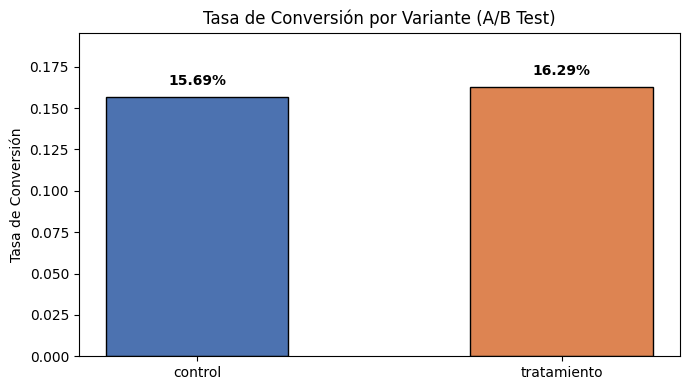

In [22]:
# 5. Intervalos de confianza por variante
from statsmodels.stats.proportion import proportion_confint

alpha = 0.05
for idx, row in conversion_stats.iterrows():
    ci_low, ci_upp = proportion_confint(count=row['conversiones'],
                                        nobs=row['total'],
                                        alpha=alpha,
                                        method='normal')
    print(f"IC 95% para '{row['variante']}': tasa = {row['tasa_conversion']:.4f} → [{ci_low:.4f}, {ci_upp:.4f}]")

# 6. Visualización comparativa de tasas
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
bars = plt.bar(conversion_stats['variante'], conversion_stats['tasa_conversion'],
               color=['#4C72B0', '#DD8452'], edgecolor='black', width=0.5)
plt.ylabel('Tasa de Conversión')
plt.title('Tasa de Conversión por Variante (A/B Test)')
plt.ylim(0, max(conversion_stats['tasa_conversion']) * 1.2)
for bar, val in zip(bars, conversion_stats['tasa_conversion']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.2%}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()


El experimento no encontró diferencia estadísticamente significativa entre la UI actual y la nueva (p = 0.4161, muy por encima del umbral de 0.05). En términos simples: no se puede descartar que la diferencia observada sea puro ruido aleatorio.

Los números clave
Qué     Valor
Mejora observada +0.60 pp (15.69% → 16.29%)
¿Es concluyente?❌ No
¿Es perjudicial el tratamiento?❌ Tampoco

El punto crítico que no hay que perder de vista
"No significativo" ≠ "No funciona."
El experimento probablemente tiene potencia insuficiente — es decir, la muestra (~10,000 usuarios) puede ser demasiado pequeña para detectar una diferencia real de 0.60 pp. El resultado es inconclusivo, no negativo.

¿Qué hacer ahora? (en orden de prioridad)

Calcular el tamaño de muestra correcto — determinar cuántos usuarios se necesitan para detectar 0.60 pp con ≥80% de potencia antes de concluir algo.
Extender el experimento — acumular más observaciones si el análisis de potencia lo confirma.
Segmentar por dispositivo y país — el efecto puede existir en mobile o en mercados específicos aunque no sea visible en el agregado.
Revisar métricas secundarias — tiempo en checkout, tasa de abandono; pueden contar una historia que la conversión sola no muestra.
Evaluar costo-beneficio pragmático — si implementar la nueva UI tiene costo mínimo, +60 conversiones/mes proyectadas pueden justificarse aun sin significancia formal.


Decisión recomendada

No descartar la nueva UI. No implementarla todavía. Repetir el experimento con muestra calculada correctamente.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

RappiPlus opera en Argentina, Colombia y México con un modelo de suscripción diseñado para aumentar la frecuencia de compra
El negocio es rentable con un Profit de $5.91M, siendo Argentina el mercado líder con $21M en ventas
. La categoría de Electrónica es la más eficiente, reteniendo un 90.26% de ganancia bruta sobre su facturación
. Se recomienda priorizar el inventario y las campañas de Electrónica para maximizar el retorno neto, ya que categorías como Hogar y Moda tienen costos de producción proporcionalmente más altos
. Aunque el modelo es saludable, el análisis del funnel secuencial muestra que la mayor fuga relativa de usuarios con intención de compra ocurre en la etapa final: un 22.35% de los usuarios que ingresan su pago no completan la compra. Es urgente auditar la pasarela de pagos. Una mejora del 15% en la eficiencia de conversión inicial, como se muestra en el escenario simulado, potenciaría exponencialmente el Revenue final


---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard


https://drive.google.com/file/d/1EwYl9YkvpuJd4bujqTTd-cmVolKyFX5I/view?usp=sharing